# Maliar–Maliar–Winant Deep Learning Method: Krusell–Smith Model in Julia

This notebook follows the teaching order of RBC.ipynb:

1. introduce the economic model;
2. define and draw the neural-network policy;
3. derive the loss function;
4. show how simulated training data are generated;
5. train the network;
6. evaluate the solution.

We follow the continuous-shock finite-agent Krusell–Smith example in Maliar, Maliar, and Winant (2021), rather than the original paper's two-state employment process.

## 1) Krusell–Smith Heterogeneous-Agent Model

### 1.1 Household problem

Household $i$ chooses consumption and next-period capital:

$$
\max E_0\sum_{t=0}^{\infty}\beta^t
\frac{(c_t^i)^{1-\gamma}-1}{1-\gamma}
$$

subject to

$$
c_t^i+k_{t+1}^i=w_t^i,
\qquad k_{t+1}^i\ge0,
$$

$$
w_{t+1}^i=(1-\delta+r_{t+1})k_{t+1}^i
+q_{t+1}y_{t+1}^i.
$$

Cash on hand $w_t^i$ is split between current consumption and savings. The inequality $k_{t+1}^i\ge0$ is the no-borrowing constraint.

### 1.2 Production and prices

Per-household aggregate capital is

$$
K_t=\frac{1}{N}\sum_{i=1}^N k_t^i.
$$

Mean labor productivity is normalized to one, so output and competitive prices are

$$
Y_t=z_tAK_t^\alpha,
$$

$$
r_t=z_tA\alpha K_t^{\alpha-1},
\qquad
q_t=z_tA(1-\alpha)K_t^\alpha.
$$

Household decisions determine $K_{t+1}$. Aggregate capital determines next-period prices, and prices determine every household's next-period wealth.

### 1.3 Shocks and the state

Idiosyncratic and aggregate productivity follow log AR(1) processes:

$$
\log y_{t+1}^i
=\rho_y\log y_t^i+\sigma_y\epsilon_{y,t+1}^i-d_y,
\qquad \epsilon_{y,t+1}^i\sim N(0,1),
$$

$$
\log z_{t+1}
=\rho_z\log z_t+\sigma_z\epsilon_{z,t+1}-d_z,
\qquad \epsilon_{z,t+1}\sim N(0,1).
$$

The drift corrections center productivity levels near one. The code truncates productivity at two unconditional standard deviations and normalizes the cross-sectional mean of $y_{t+1}^i$ to one.

The complete state is

$$
s_t=(W_t,Y_t,z_t)
=((w_t^1,\ldots,w_t^N),(y_t^1,\ldots,y_t^N),z_t),
$$

with dimension $2N+1$.

### 1.4 Euler equation and borrowing constraint

Let $\mu_t^i$ denote the normalized multiplier. The Euler condition is

$$
\mu_t^i
=\beta E_t\left[
\left(\frac{c_t^i}{c_{t+1}^i}\right)^\gamma
(1-\delta+r_{t+1})
\right].
$$

The Kuhn–Tucker conditions are

$$
k_{t+1}^i\ge0,\qquad
1-\mu_t^i\ge0,\qquad
k_{t+1}^i(1-\mu_t^i)=0.
$$

If savings are positive, $\mu_t^i=1$. If the household is borrowing constrained, $k_{t+1}^i=0$ and $\mu_t^i<1$.

## 2) Julia Setup

This is a teaching notebook, so the economically important implementation stays visible here:

- model calibration and steady state;
- the hand-written neural network;
- policy and state-transition functions;
- Euler/AiO loss;
- Adam and the training loop.

Only supporting material stays in src:

- NetworkDiagram.jl: architecture and training-flow diagrams;
- Diagnostics.jl: repetitive evaluation and plotting helpers.

In [112]:
using Pkg

function find_project_root(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not find Project.toml from $(start_dir)")
        dir = parent
    end
end

project_root = find_project_root()
Pkg.activate(project_root)

using Random
using LinearAlgebra
using Statistics
using Printf
using Flux
using Plots
using Markdown

include(joinpath(project_root, "src", "NetworkDiagram.jl"))

  Activating project at `c:\Users\86132\Desktop\Yuxuan ZHAO\minnesota\Research\DeepLearningMacro`


plot_ks_training_flow_diagram

## 3) Calibration and Steady State

At $y^i=z=1$, the deterministic steady state satisfies

$$
\frac{1}{\beta}
=1-\delta+\alpha AK_{ss}^{\alpha-1}.
$$

Then

$$
Y_{ss}=AK_{ss}^{\alpha},
\qquad
C_{ss}=Y_{ss}-\delta K_{ss},
$$

$$
W_{ss}=Y_{ss}+(1-\delta)K_{ss},
\qquad
\xi_{ss}=\frac{C_{ss}}{W_{ss}}.
$$

### 3.1 Parameters used in the executable run

| Object | Notebook value | Role |
|---|---:|---|
| households $N$ | 200 | finite representation of the wealth-productivity distribution |
| hidden width $H$ | 32 | neurons in each of two hidden layers |
| network input | $2N+3=403$ | full $W$, full $Y$, aggregate $z$, and household $i$'s own $(w_i,y_i)$ |
| network outputs | 2 | consumption share $\xi_i$ and Euler multiplier $\mu_i$ |
| independent economies $B$ | 20 | current-state mini-batch |
| future branches | 2 per economy | AiO cross product |
| Adam updates | 2000 | training budget |
| learning rate | $10^{-3}$ | Adam step size |
| evaluation shocks | 128 | out-of-sample conditional Euler integration |
| evaluation simulation | 1000 periods after 200 burn-in | aggregate and inequality diagnostics |

This is larger than the released reference notebook ($N=50$, $32\times32$) while remaining practical on a CPU. The JME paper also reports $64\times64$ networks and sensitivity experiments up to $N=1000$ agents.

The code cell below performs four tasks: it stores all economic and numerical parameters in `KSParams`, computes the deterministic steady state, instantiates the $N=200$, $H=32$ configuration, and prints the values that should be checked before training.

In [113]:
"""
Calibration and numerical choices for the Maliar--Maliar--Winant deep-learning
solution of the Krusell--Smith economy.

The state contains cash on hand and idiosyncratic labor productivity for every
agent, plus aggregate productivity. Set `agents=50` to match the reference code.
"""
Base.@kwdef struct KSParams
    alpha::Float64 = 0.36
    delta::Float64 = 0.08
    A::Float64 = 1.0
    beta::Float64 = 0.96
    gamma::Float64 = 1.0

    rho_z::Float64 = 0.90
    sigma_z::Float64 = 0.01
    rho_y::Float64 = 0.95
    sigma_y::Float64 = 0.20

    agents::Int = 200
    hidden::Int = 32
    xi_min::Float64 = 1e-4
    xi_max::Float64 = 1.0 - 1e-4
    wealth_cap_multiple::Float64 = 4.0
    productivity_sd_bound::Float64 = 2.0
    mu_log_bound::Float64 = 8.0
end

"""Deterministic steady state with unit labor and aggregate productivity."""
function steady_state(p::KSParams)
    K = ((1 / p.beta - (1 - p.delta)) / (p.alpha * p.A))^(1 / (p.alpha - 1))
    Y = p.A * K^p.alpha
    rental = p.A * p.alpha * K^(p.alpha - 1)
    wage = p.A * (1 - p.alpha) * K^p.alpha
    W = (1 - p.delta + rental) * K + wage
    C = Y - p.delta * K
    xi = C / W
    return (; K, Y, C, W, xi, rental, wage)
end


par = KSParams(agents=200, hidden=32)
ss = steady_state(par)

@printf("Preferences: beta=%.2f, gamma=%.1f\n", par.beta, par.gamma)
@printf("Technology: alpha=%.2f, delta=%.2f\n", par.alpha, par.delta)
@printf("Aggregate shock: rho_z=%.2f, sigma_z=%.3f\n", par.rho_z, par.sigma_z)
@printf("Individual shock: rho_y=%.2f, sigma_y=%.2f\n", par.rho_y, par.sigma_y)
@printf("K_ss=%.4f, W_ss=%.4f, C_ss=%.4f, xi_ss=%.4f\n",
    ss.K, ss.W, ss.C, ss.xi)

Preferences: beta=0.96, gamma=1.0
Technology: alpha=0.36, delta=0.08
Aggregate shock: rho_z=0.90, sigma_z=0.010
Individual shock: rho_y=0.95, sigma_y=0.20
K_ss=5.4468, W_ss=6.8519, C_ss=1.4051, xi_ss=0.2051


## 4) Neural-Network Policy Rule

### 4.1 Input

The same network is used for every household. For household $i$, its input is

$$
x_t^i=
\left[
\widetilde W_t,\widetilde Y_t,\widetilde z_t,
\widetilde w_t^i,\widetilde y_t^i
\right]\in\mathbb R^{2N+3}.
$$

The input contains the full normalized distribution, aggregate productivity, and household $i$'s own state. The own variables appear twice: once inside the distribution and once to identify which household is choosing.

### 4.2 Hidden layers and activation

There are two hidden layers. Both use the logistic sigmoid

$$
\sigma(a)=\frac{1}{1+e^{-a}},
\qquad
\sigma'(a)=\sigma(a)[1-\sigma(a)].
$$

The forward pass is

$$
h_1=\sigma(W_1x_t^i+b_1),
\qquad h_1\in(0,1)^H,
$$

$$
h_2=\sigma(W_2h_1+b_2),
\qquad h_2\in(0,1)^H,
$$

$$
\begin{bmatrix}a_\xi^i\\a_\mu^i\end{bmatrix}
=W_3h_2+b_3.
$$

The last layer is linear and returns two raw numbers.

### 4.3 Parameter storage and initialization

Like `RBC.ipynb`, every weight and bias is stored in one vector $\theta$. This code cell does the following:

1. computes the input dimension $D=2N+3$;
2. computes the total parameter count

   $$HD+H+H^2+H+2H+2;$$

3. maps slices of $\theta$ into $(W_1,b_1,W_2,b_2,W_3,b_3)$ without creating separate trainable objects;
4. initializes small random weights and zero output biases.

For $N=200$ and $H=32$, the network has $D=403$ inputs and 14,050 trainable parameters.

In [114]:
logit(x) = log(x / (1 - x))

function sigmoid_stable(x)
    if x >= 0
        q = exp(-x)
        return inv(1 + q)
    else
        q = exp(x)
        return q / (1 + q)
    end
end

input_dimension(p::KSParams) = 2 * p.agents + 3

"""Number of parameters in the two-hidden-layer, two-output network."""
function nparams(p::KSParams)
    D, H = input_dimension(p), p.hidden
    return H * D + H + H * H + H + 2 * H + 2
end

function _unpack(theta, p::KSParams)
    D, H = input_dimension(p), p.hidden
    i = 1
    W1 = reshape(@view(theta[i:(i + H * D - 1)]), H, D)
    i += H * D
    b1 = @view(theta[i:(i + H - 1)])
    i += H
    W2 = reshape(@view(theta[i:(i + H * H - 1)]), H, H)
    i += H * H
    b2 = @view(theta[i:(i + H - 1)])
    i += H
    W3 = reshape(@view(theta[i:(i + 2 * H - 1)]), 2, H)
    i += 2 * H
    b3 = @view(theta[i:(i + 1)])
    return W1, b1, W2, b2, W3, b3
end

"""Small-weight initialization centered on the deterministic policy and mu=1."""
function init_theta(rng::AbstractRNG, p::KSParams, ss=steady_state(p); scale=0.02)
    theta = scale .* randn(rng, nparams(p))
    D, H = input_dimension(p), p.hidden
    b3_start = H * D + H + H * H + H + 2 * H + 1
    theta[b3_start:(b3_start + 1)] .= 0.0
    return theta
end

init_theta

### 4.4 Normalize the state and run the two hidden layers

The next cell constructs the $2N+3$-dimensional input for every household. It then applies

$$
h_1=\sigma(W_1x+b_1),
\qquad
h_2=\sigma(W_2h_1+b_2),
\qquad
a=W_3h_2+b_3.
$$

The code cell first normalizes each economic state:

$$\widetilde w=2w/w_{max}-1,\qquad \widetilde y=\log y/(2\sigma_{y,\infty}),\qquad \widetilde z=\log z/(2\sigma_{z,\infty}).$$

It then constructs one column $x_t^i$ for every household in every economy. With batch size $B$, the resulting matrix has shape

$$X\in\mathbb R^{(2N+3)\times (NB)}.$$

Finally it evaluates both hidden layers and returns two raw outputs per household. The tensor construction is mutation-free because future inputs depend on current saving and must remain differentiable with respect to $\theta$.

In [115]:
"""A batch of identical deterministic steady states."""
function initial_state(batch_size::Int, p::KSParams, ss=steady_state(p))
    w = fill(ss.W, batch_size, p.agents)
    y = ones(batch_size, p.agents)
    z = ones(batch_size)
    return (; w, y, z)
end

function _state_bounds(p::KSParams, ss)
    y_log_sd = p.sigma_y / sqrt(1 - p.rho_y^2)
    z_log_sd = p.sigma_z / sqrt(1 - p.rho_z^2)
    w_max = p.wealth_cap_multiple * ss.W
    return (; y_log_sd, z_log_sd, w_max)
end

function _normalize_state(w, y, z, p::KSParams, ss)
    bounds = _state_bounds(p, ss)
    normw = 2 .* w ./ bounds.w_max .- 1
    normy = log.(max.(y, 1e-12)) ./ max(p.productivity_sd_bound * bounds.y_log_sd, 1e-8)
    normz = log.(max.(z, 1e-12)) ./ max(p.productivity_sd_bound * bounds.z_log_sd, 1e-8)
    return normw, normy, normz
end

"""
Construct the paper's full-distribution input. Each column contains all agents'
normalized wealth and productivity, aggregate productivity, and agent i's own
wealth and productivity.
"""
function _network_input(w, y, z, p::KSParams, ss)
    B, N = size(w)
    N == p.agents || throw(DimensionMismatch("state has $N agents; parameters expect $(p.agents)"))
    size(y) == size(w) || throw(DimensionMismatch("w and y must have the same shape"))
    length(z) == B || throw(DimensionMismatch("z must contain one value per batch observation"))

    normw, normy, normz = _normalize_state(w, y, z, p, ss)
    # Mutation-free construction is required because next-period inputs depend on theta.
    full_w = reshape(
        permutedims(repeat(reshape(normw, B, N, 1), 1, 1, N), (2, 3, 1)),
        N, N * B,
    )
    full_y = reshape(
        permutedims(repeat(reshape(normy, B, N, 1), 1, 1, N), (2, 3, 1)),
        N, N * B,
    )
    aggregate_z = reshape(vec(repeat(reshape(normz, 1, B), N, 1)), 1, N * B)
    own_w = reshape(vec(permutedims(normw, (2, 1))), 1, N * B)
    own_y = reshape(vec(permutedims(normy, (2, 1))), 1, N * B)
    return vcat(full_w, full_y, aggregate_z, own_w, own_y)
end

function _network_raw(theta, x, p::KSParams)
    W1, b1, W2, b2, W3, b3 = _unpack(theta, p)
    h1 = sigmoid_stable.(W1 * x .+ reshape(b1, :, 1))
    h2 = sigmoid_stable.(W2 * h1 .+ reshape(b2, :, 1))
    return W3 * h2 .+ reshape(b3, :, 1)
end

_network_raw (generic function with 1 method)

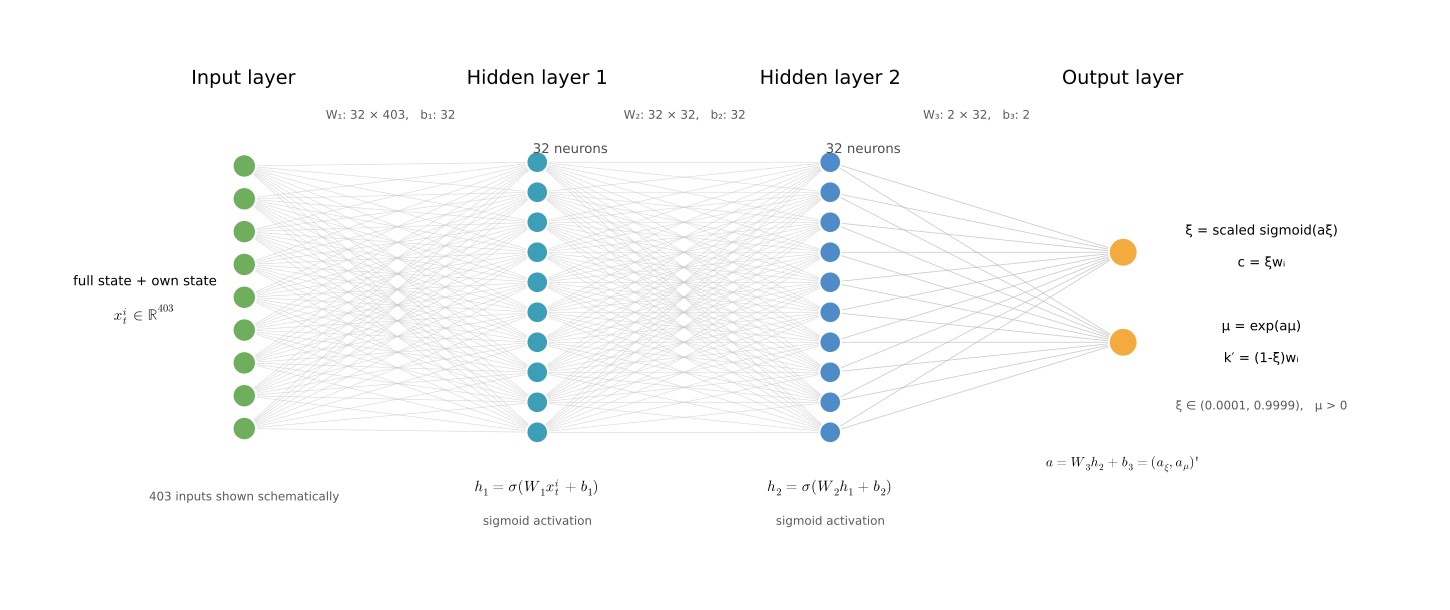

In [116]:
plot_ks_policy_network_diagram(
    agents=par.agents,
    hidden=par.hidden,
    xi_min=par.xi_min,
    xi_max=par.xi_max,
)

### 4.5 Economic output transformations

The raw outputs are transformed into a consumption share and a positive multiplier:

$$
\xi_t^i
=\xi_{min}+(\xi_{max}-\xi_{min})
\sigma\left(a_\xi^i+\operatorname{logit}(\xi_{ss})\right),
$$

$$
\mu_t^i=\exp(a_\mu^i).
$$

Decisions are

$$
c_t^i=\xi_t^iw_t^i,
\qquad
k_{t+1}^i=(1-\xi_t^i)w_t^i.
$$

Therefore consumption is positive, savings are nonnegative, and the budget constraint holds by construction.

### 4.6 Policy implementation

This code cell turns the two raw network outputs into economic decisions. Its input is a state batch $(W,Y,z)$ and its output is $(\xi,\mu,c,k')$ for every household. It performs these steps:

1. call `_network_input` and `_network_raw`;
2. map the first output through a bounded sigmoid to obtain $0<\xi_i<1$;
3. exponentiate the second output to obtain $\mu_i>0$;
4. construct $c_i=\xi_iw_i$ and $k'_i=(1-\xi_i)w_i$;
5. cap extreme wealth only for numerical stability.

The following verification cell prints the architecture, parameter count, initial average policies, and the maximum budget error. The budget error should be at machine precision.

In [117]:
"""Evaluate consumption-share and multiplier policies for a state batch."""
function policy(theta, w, y, z, p::KSParams, ss=steady_state(p))
    B, N = size(w)
    raw = _network_raw(theta, _network_input(w, y, z, p, ss), p)

    qss = (ss.xi - p.xi_min) / (p.xi_max - p.xi_min)
    xi_vector = p.xi_min .+ (p.xi_max - p.xi_min) .* sigmoid_stable.(raw[1, :] .+ logit(qss))
    mu_vector = exp.(clamp.(raw[2, :], -p.mu_log_bound, p.mu_log_bound))
    xi = permutedims(reshape(xi_vector, N, B), (2, 1))
    mu = permutedims(reshape(mu_vector, N, B), (2, 1))

    w_max = p.wealth_cap_multiple * ss.W
    kp = min.((1 .- xi) .* w, w_max)
    c = max.(w .- kp, 1e-10)
    return (; xi, mu, c, kp)
end

policy

In [118]:
theta = init_theta(MersenneTwister(1234), par, ss)
state0 = initial_state(2, par, ss)
policy0 = policy(theta, state0.w, state0.y, state0.z, par, ss)

D = 2 * par.agents + 3
H = par.hidden
@printf("architecture: %d inputs -> %d sigmoid -> %d sigmoid -> 2 outputs\n", D, H, H)
@printf("parameter count: %d\n", nparams(par))
@printf("initial mean xi=%.4f; initial mean mu=%.4f\n",
    mean(policy0.xi), mean(policy0.mu))
@printf("maximum budget error: %.3e\n",
    maximum(abs.(policy0.c .+ policy0.kp .- state0.w)))

architecture: 403 inputs -> 32 sigmoid -> 32 sigmoid -> 2 outputs
parameter count: 14050
initial mean xi=0.2078; initial mean mu=1.0222
maximum budget error: 0.000e+00


## 5) Loss Function

### 5.1 Borrowing-constraint loss

Define

$$
a_t^i=1-\frac{c_t^i}{w_t^i}=1-\xi_t^i,
\qquad
b_t^i=1-\mu_t^i.
$$

The Fisher–Burmeister residual is

$$
\Phi_t^i=a_t^i+b_t^i
-\sqrt{(a_t^i)^2+(b_t^i)^2}.
$$

We have $\Phi_t^i=0$ exactly when

$$
a_t^i\ge0,\qquad b_t^i\ge0,\qquad a_t^ib_t^i=0.
$$

Its loss contribution is $E[(\Phi_t^i)^2]$.

### 5.2 Euler loss and two-shock AiO

For one future shock vector $\epsilon$, define

$$
R_t^i(\epsilon;\theta)
=\beta
\left(\frac{c_t^i}{c_{t+1}^i(\epsilon)}\right)^\gamma
[1-\delta+r_{t+1}(\epsilon)]
-\mu_t^i.
$$

The model requires

$$
E[R_t^i(\epsilon;\theta)\mid s_t]=0.
$$

Squaring one realized residual would also penalize shock variance. Draw two independent future shocks $A$ and $B$ from the same state:

$$
E[R_A^iR_B^i\mid s_t]
=E[R_A^i\mid s_t]E[R_B^i\mid s_t].
$$

Hence the mini-batch loss is

$$
\widehat{\mathcal L}(\theta)
=\frac{1}{BN}\sum_{b=1}^B\sum_{i=1}^N
\left[(\Phi_b^i)^2+R_{A,b}^iR_{B,b}^i\right].
$$

A finite AiO estimate may be negative, but its population target is nonnegative.

### 5.3 Implement shocks, prices, future branches, and the loss

The code below follows the equations above directly. The input is one current state batch, two independent shock batches, and the current parameter vector. It returns the scalar loss together with its complementarity and Euler components:

1. draw idiosyncratic and aggregate shocks;
2. construct next-period productivity;
3. aggregate household savings and compute prices;
4. evaluate the same network at each future branch;
5. combine Fisher–Burmeister and AiO Euler residuals.

A crucial variance-reduction step occurs inside `transition_productivity`: after drawing continuous idiosyncratic shocks, it rescales each simulated economy so that

$$\frac1N\sum_{i=1}^N y_{t+1}^i=1.$$

Thus finite-$N$ draws change the shape of the productivity distribution but do not create an unintended aggregate-labor shock. `next_period` then aggregates $k'_i$ to $K'$ and computes prices directly; it never estimates an aggregate forecasting rule.

In [119]:
"""Draw standardized idiosyncratic and aggregate innovations."""
function draw_shocks(rng::AbstractRNG, batch_size::Int, p::KSParams)
    return (; eps_y=randn(rng, batch_size, p.agents), eps_z=randn(rng, batch_size))
end

"""Advance idiosyncratic and aggregate productivity in levels."""
function transition_productivity(y, z, shocks, p::KSParams)
    bounds = _state_bounds(p, steady_state(p))
    y_bound = p.productivity_sd_bound * bounds.y_log_sd
    z_bound = p.productivity_sd_bound * bounds.z_log_sd

    log_y_next = p.rho_y .* log.(max.(y, 1e-12)) .+
                 p.sigma_y .* shocks.eps_y .-
                 0.5 * p.sigma_y^2 / (1 + p.rho_y)
    log_y_next = clamp.(log_y_next, -y_bound, y_bound)
    y_next_raw = exp.(log_y_next)
    y_next = y_next_raw ./ mean(y_next_raw; dims=2)

    log_z_next = p.rho_z .* log.(max.(z, 1e-12)) .+
                 p.sigma_z .* shocks.eps_z .-
                 0.5 * p.sigma_z^2 / (1 + p.rho_z)
    z_next = exp.(clamp.(log_z_next, -z_bound, z_bound))
    return y_next, z_next
end

"""Competitive prices and next-period cash on hand."""
function next_period(kp, y_next, z_next, p::KSParams)
    B = size(kp, 1)
    aggregate_k = vec(mean(kp; dims=2))
    rental = p.A .* z_next .* p.alpha .* aggregate_k .^ (p.alpha - 1)
    wage = p.A .* z_next .* (1 - p.alpha) .* aggregate_k .^ p.alpha
    gross_return = 1 - p.delta .+ rental
    wealth_next = reshape(gross_return, B, 1) .* kp .+ reshape(wage, B, 1) .* y_next
    return (; aggregate_k, rental, wage, gross_return, wealth_next)
end

function _future_branch(theta, current_policy, y, z, shocks, p::KSParams, ss)
    y_next, z_next = transition_productivity(y, z, shocks, p)
    prices = next_period(current_policy.kp, y_next, z_next, p)
    next_policy = policy(theta, prices.wealth_next, y_next, z_next, p, ss)
    euler = p.beta .* (current_policy.c ./ next_policy.c) .^ p.gamma .*
            reshape(prices.gross_return, :, 1) .- current_policy.mu
    return (; y_next, z_next, prices, next_policy, euler)
end

"""AiO objective components for two conditionally independent shock branches."""
function aio_loss_components(theta, state, shocks_a, shocks_b, p::KSParams, ss=steady_state(p))
    current = policy(theta, state.w, state.y, state.z, p, ss)
    branch_a = _future_branch(theta, current, state.y, state.z, shocks_a, p, ss)
    branch_b = _future_branch(theta, current, state.y, state.z, shocks_b, p, ss)

    a = 1 .- current.xi
    b = 1 .- current.mu
    fisher_burmeister = a .+ b .- sqrt.(a .^ 2 .+ b .^ 2)
    complementarity = mean(fisher_burmeister .^ 2)
    euler = mean(branch_a.euler .* branch_b.euler)
    return (; loss=complementarity + euler, complementarity, euler,
            current, branch_a, branch_b)
end

aio_loss(theta, state, shocks_a, shocks_b, p::KSParams, ss=steady_state(p)) =
    aio_loss_components(theta, state, shocks_a, shocks_b, p, ss).loss

aio_loss (generic function with 2 methods)

In [120]:
rng_loss = MersenneTwister(7)
shock_a = draw_shocks(rng_loss, size(state0.w, 1), par)
shock_b = draw_shocks(rng_loss, size(state0.w, 1), par)
initial_loss = aio_loss_components(theta, state0, shock_a, shock_b, par, ss)

@printf("initial total loss = %.6e\n", initial_loss.loss)
@printf("  Fisher–Burmeister term = %.6e\n", initial_loss.complementarity)
@printf("  AiO Euler term = %.6e\n", initial_loss.euler)

initial total loss = 8.236088e-04
  Fisher–Burmeister term = 5.074136e-04
  AiO Euler term = 3.161952e-04


## 6) Simulation and Training Data

There is no external dataset and no analytical policy label. The model produces its own training observations.

One observation is

$$
\mathcal D_b=
(s_{t,b},\epsilon_{A,b}^y,\epsilon_{A,b}^z,
\epsilon_{B,b}^y,\epsilon_{B,b}^z).
$$

A mini-batch contains $B$ simulated economies. Each economy contains $N$ households and two independent future shock branches.

Given $s_t$:

1. use the NN to compute $\xi_t,\mu_t,c_t,k_{t+1}$;
2. draw shocks and construct $y_{t+1},z_{t+1}$;
3. aggregate capital and compute next-period prices;
4. compute $w_{t+1}$;
5. evaluate the same NN at the next state.

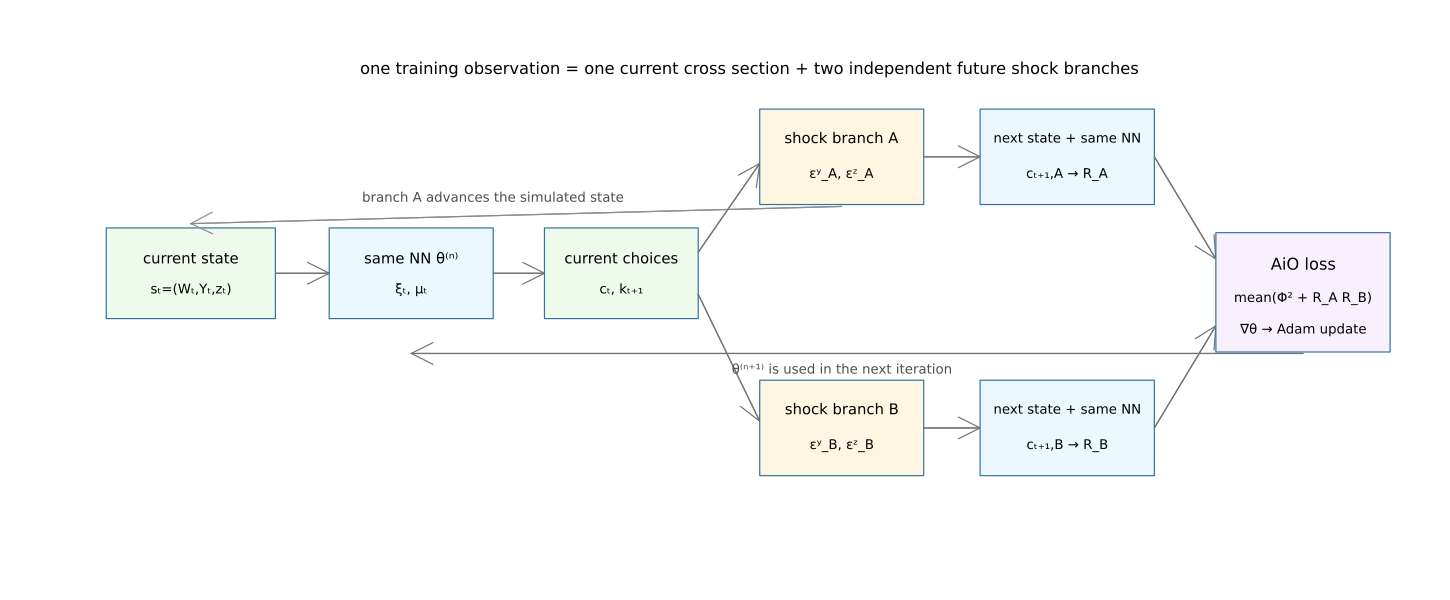

In [121]:
plot_ks_training_flow_diagram()

### 6.1 Generate an endogenous training-state batch

The helper below generates an endogenous current-state batch before optimization. Starting from the deterministic steady state, each warm-up period:

1. evaluates the current network for all $BN$ households;
2. draws one idiosyncratic shock vector and one aggregate shock for each economy;
3. computes $y'$, $z'$, $K'$, prices, and next cash on hand $W'$;
4. replaces the current batch by $(W',Y',z')$.

It is not an external data loader. Its output is the simulated state distribution on which the equilibrium loss is evaluated. The following preview cell prints one household's current state, policy, future wealth, and Euler residual in both AiO branches so the data flow can be inspected before training.

In [122]:
function _advance_state(theta, state, shocks, p::KSParams, ss)
    current = policy(theta, state.w, state.y, state.z, p, ss)
    y_next, z_next = transition_productivity(state.y, state.z, shocks, p)
    prices = next_period(current.kp, y_next, z_next, p)
    return (; w=prices.wealth_next, y=y_next, z=z_next)
end

"""Generate a stochastic state batch before training, for inspection or warm-up."""
function simulate_training_state(theta, p::KSParams, ss=steady_state(p);
                                 periods=40, batch_size=8, seed=2025)
    rng = MersenneTwister(seed)
    state = initial_state(batch_size, p, ss)
    for _ in 1:periods
        state = _advance_state(theta, state, draw_shocks(rng, batch_size, p), p, ss)
    end
    return state
end

simulate_training_state

In [123]:
# Inspect one simulated training observation before optimization.
preview_state = simulate_training_state(theta, par, ss;
    periods=30, batch_size=4, seed=2025)
preview_rng = MersenneTwister(2026)
preview_a = draw_shocks(preview_rng, 4, par)
preview_b = draw_shocks(preview_rng, 4, par)
preview = aio_loss_components(theta, preview_state, preview_a, preview_b, par, ss)

b, i = 1, 1
@printf("batch shapes: w=%s, y=%s, z=%s\n",
    string(size(preview_state.w)), string(size(preview_state.y)), string(size(preview_state.z)))
@printf("current state: w=%.4f, y=%.4f, z=%.4f\n",
    preview_state.w[b,i], preview_state.y[b,i], preview_state.z[b])
@printf("current policy: xi=%.4f, mu=%.4f, c=%.4f, k'=%.4f\n",
    preview.current.xi[b,i], preview.current.mu[b,i],
    preview.current.c[b,i], preview.current.kp[b,i])
@printf("branch A: next w=%.4f, Euler R=%.4f\n",
    preview.branch_a.prices.wealth_next[b,i], preview.branch_a.euler[b,i])
@printf("branch B: next w=%.4f, Euler R=%.4f\n",
    preview.branch_b.prices.wealth_next[b,i], preview.branch_b.euler[b,i])

batch shapes: w=(4, 200), y=(4, 200), z=(4,)
current state: w=5.3615, y=0.7457, z=0.9585
current policy: xi=0.2078, mu=1.0223, c=1.1141, k'=4.2474
branch A: next w=5.1261, Euler R=0.0248
branch B: next w=5.3148, Euler R=-0.0147


## 7) Stochastic Training

At iteration $n$:

1. draw two future shock batches;
2. compute $\widehat{\mathcal L}(\theta^{(n)})$;
3. use automatic differentiation:

   $$
   g^{(n)}=\nabla_\theta
   \widehat{\mathcal L}(\theta^{(n)});
   $$

4. update $\theta$ with Adam;
5. advance the simulated state with branch A;
6. repeat with new shocks.

The NN receives no target consumption data. It learns by reducing equilibrium-condition errors.

### 7.1 Adam and the complete training loop

The full optimizer and training function remain visible. `AdamState` stores the first and second gradient moments. At each of the 500 iterations, `train!`:

1. holds the current batch of eight economies fixed;
2. draws two independent future shock branches;
3. evaluates the current and both future policies with the same $\theta$;
4. differentiates the complete loss with `Flux.gradient`;
5. applies one Adam update with learning rate $10^{-3}$;
6. records total, FB, and AiO Euler losses;
7. advances the state batch with branch A.

The training call below prints a line every 50 updates. A successful teaching run should show a clear decline in the smoothed magnitude of the loss components, but the signed AiO Euler cross product can fluctuate around zero.

In [124]:
mutable struct AdamState
    m::Vector{Float64}
    v::Vector{Float64}
    t::Int
end

AdamState(n::Int) = AdamState(zeros(n), zeros(n), 0)

function _adam_step!(theta, grad, state::AdamState; lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8)
    state.t += 1
    state.m .= beta1 .* state.m .+ (1 - beta1) .* grad
    state.v .= beta2 .* state.v .+ (1 - beta2) .* (grad .^ 2)
    mhat = state.m ./ (1 - beta1^state.t)
    vhat = state.v ./ (1 - beta2^state.t)
    theta .-= lr .* mhat ./ (sqrt.(vhat) .+ eps)
    return theta
end


"""Train on an evolving simulated cross section using the two-shock AiO objective."""
function train!(theta, p::KSParams, ss=steady_state(p);
                steps=2000, batch_size=20, lr=1e-3, seed=2026, display_step=100)
    rng = MersenneTwister(seed)
    state = initial_state(batch_size, p, ss)
    optimizer = AdamState(length(theta))
    loss_history = Float64[]
    complementarity_history = Float64[]
    euler_history = Float64[]

    for iteration in 1:steps
        shocks_a = draw_shocks(rng, batch_size, p)
        shocks_b = draw_shocks(rng, batch_size, p)
        loss_function = th -> aio_loss(th, state, shocks_a, shocks_b, p, ss)
        gradient = Flux.gradient(loss_function, theta)[1]
        all(isfinite, gradient) || error("non-finite gradient at iteration $iteration")
        _adam_step!(theta, gradient, optimizer; lr=lr)

        components = aio_loss_components(theta, state, shocks_a, shocks_b, p, ss)
        push!(loss_history, components.loss)
        push!(complementarity_history, components.complementarity)
        push!(euler_history, components.euler)
        state = _advance_state(theta, state, shocks_a, p, ss)

        if iteration == 1 || iteration % display_step == 0
            println("step $(lpad(iteration, 5)) | loss=$(round(components.loss, sigdigits=5)) " *
                    "| FB=$(round(components.complementarity, sigdigits=4)) " *
                    "| AiO Euler=$(round(components.euler, sigdigits=4))")
        end
    end

    return (; theta, state, loss_history, complementarity_history, euler_history)
end

train!

In [125]:
theta = init_theta(MersenneTwister(1234), par, ss)
result = train!(theta, par, ss;
    steps=2000,
    batch_size=20,
    lr=1e-3,
    seed=2026,
    display_step=100,
)

step     1 | loss=6.1604e-5 | FB=9.411e-6 | AiO Euler=5.219e-5
step   100 | loss=0.0016843 | FB=6.047e-6 | AiO Euler=0.001678
step   200 | loss=0.0016365 | FB=1.149e-5 | AiO Euler=0.001625
step   300 | loss=0.0012906 | FB=4.329e-5 | AiO Euler=0.001247
step   400 | loss=0.00092833 | FB=9.532e-5 | AiO Euler=0.000833
step   500 | loss=0.00047218 | FB=0.0001116 | AiO Euler=0.0003606
step   600 | loss=0.00049822 | FB=8.254e-5 | AiO Euler=0.0004157
step   700 | loss=0.00065572 | FB=5.504e-5 | AiO Euler=0.0006007
step   800 | loss=0.00023455 | FB=2.497e-5 | AiO Euler=0.0002096
step   900 | loss=0.00032934 | FB=1.565e-5 | AiO Euler=0.0003137
step  1000 | loss=0.00048078 | FB=1.512e-5 | AiO Euler=0.0004657
step  1100 | loss=0.00021977 | FB=1.396e-5 | AiO Euler=0.0002058
step  1200 | loss=0.00058782 | FB=1.427e-5 | AiO Euler=0.0005736
step  1300 | loss=0.00046863 | FB=2.04e-5 | AiO Euler=0.0004482
step  1400 | loss=0.00060204 | FB=1.528e-5 | AiO Euler=0.0005868
step  1500 | loss=0.00049841 | FB=

(theta = [-0.02020266809387453, 0.012191726027292668, -0.011255710891878832, 0.014755708516775061, -0.012848560452822913, 0.053400059603907056, 0.008577778406254174, -0.0066198484864414455, -0.02353734951248289, -0.022895215733363616  …  -0.00424164075226167, 0.010585570381866324, -0.14571574520372205, -0.01477647813532536, 0.16610244595235182, 0.0017991447795439892, -0.2716238027945735, 0.0034202187530236955, 0.04708279958235726, -0.0007933268963562078], state = (w = [2.418845298477615 4.0453297399081105 … 3.583771199876495 15.038673705061907; 10.299614426830571 23.069016465194153 … 2.5767473283214395 2.8834694396183327; … ; 2.9343999789607227 2.6154718063237796 … 16.881541652105938 3.4238793127049636; 2.001868850943844 5.1318940031768845 … 1.9547098577636746 2.4506304357675726], y = [0.5869485465897509 0.832264400952704 … 1.1228376245598382 0.8959987944019215; 0.7643313050162491 1.226370680837796 … 0.6569885560738792 0.8596967807632013; … ; 0.6222729037209516 0.2715430994780318 … 0.4

## 8) Diagnostics

Since this model has no closed-form policy benchmark, diagnostics must check both household optimality and simulated equilibrium behavior. The remaining cells perform these tasks:

- training-loss components;
- out-of-sample conditional Euler errors;
- Fisher–Burmeister errors;
- simulated aggregate capital and capital inequality;
- policy-function slices;
- approximate aggregation.

First, the notebook plots the total loss, the nonnegative FB component, and the absolute signed AiO Euler component. Second, it averages Euler residuals over 128 fresh shocks at the final state. Third, it simulates 1000 new periods after a 200-period burn-in and reports aggregate capital, inequality, and a KS-style regression. That regression is diagnostic only and is not used during training.

In [126]:
# Diagnostics are supporting checks rather than the core solution method.
include(joinpath(project_root, "src", "Diagnostics.jl"))

policy_slice

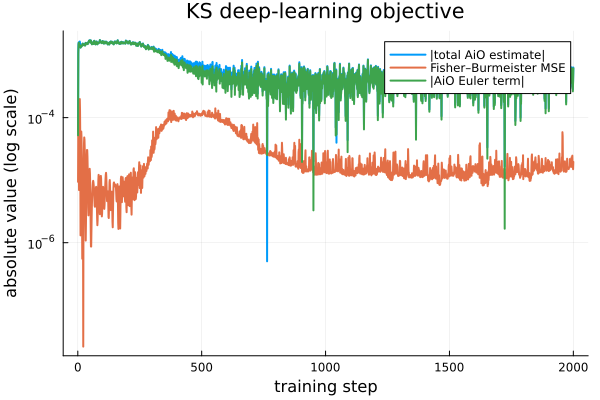

In [127]:
p_loss = plot(abs.(result.loss_history) .+ 1e-14,
    yscale=:log10, lw=2, label="|total AiO estimate|",
    xlabel="training step", ylabel="absolute value (log scale)")
plot!(p_loss, result.complementarity_history .+ 1e-14,
    lw=2, label="Fisher–Burmeister MSE")
plot!(p_loss, abs.(result.euler_history) .+ 1e-14,
    lw=2, label="|AiO Euler term|")
title!(p_loss, "KS deep-learning objective")
p_loss

### Interpreting the training-loss figure

The figure should not be read like a deterministic optimization curve. At iteration $n$, the notebook evaluates

$$
\widehat L_n=\frac{1}{BN}\sum_{b=1}^B\sum_{i=1}^N\left[\Phi_{b,i}^2+R_{A,b,i}R_{B,b,i}\right]
$$

on a newly simulated current-state batch and two newly drawn future-shock branches. The current state also advances after every update. Consequently, adjacent points use different $(W,Y,z)$ distributions and different shocks; the plotted estimator is not expected to decrease monotonically.

The orange Fisher--Burmeister component falls rapidly because feasibility and complementarity are relatively easy to learn near the initial state. Its temporary rise around the middle of training is informative: as the policy generates a more dispersed endogenous state distribution, the network encounters households closer to the borrowing constraint and must relearn the KKT condition on those states.

The green AiO Euler component dominates later training. It is a signed cross-product estimator. Conditional independence gives

$$
E[R_AR_B\mid S]=E[R_A\mid S]E[R_B\mid S]=\bar R(S)^2,
$$

but a finite-batch realization can be positive or negative. The plot displays its absolute value, so estimates that cross zero appear as sharp downward spikes. With `batch_size=20`, there are twenty independent aggregate shocks per branch--not $20\times200$ independent aggregate observations, because the 200 households inside one economy share the same $z'$, prices, and aggregate capital. Near a solution, the true gradient becomes small while this Monte Carlo noise remains, producing the visible noise floor. Adam adapts coordinate-wise scaling, but the base learning rate remains fixed unless a scheduler is added.

For the current run, the held-out diagnostics printed below are more meaningful than the last training point. Judge convergence from the median and upper-tail conditional Euler errors together with the mean absolute FB residual; these quantities must be recomputed after changing $N$ or the batch size.

To obtain a cleaner and more accurate solution, keep a fixed validation set of simulated states and evaluate each state with many future shocks; refresh a replay buffer only periodically instead of discarding every state after one update; train longer with a declining base learning rate; increase the number of independent economy paths; and compare several random seeds. Convergence should be judged from fixed-state conditional Euler errors and their tail quantiles, not from whether the signed training estimator approaches machine zero.

mean log10 Euler error = -1.9425
median log10 Euler error = -1.8561
p90 log10 Euler error = -1.4007
mean absolute FB residual = 3.4886e-03


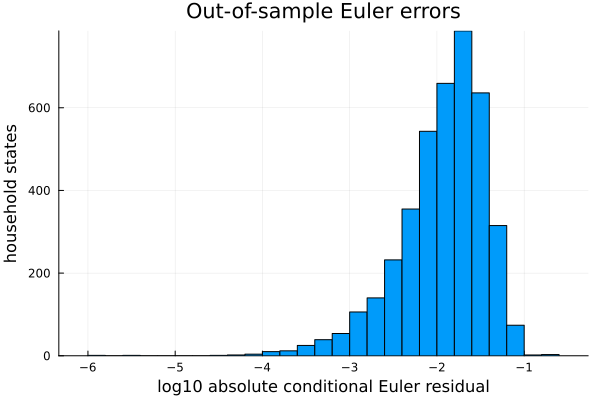

In [128]:
diagnostics = conditional_residuals(result.theta, result.state, par, ss;
    n_shocks=128, seed=99)
log_euler_error = log10.(abs.(vec(diagnostics.euler)) .+ 1e-12)
fb_error = abs.(vec(diagnostics.fisher_burmeister))

@printf("mean log10 Euler error = %.4f\n", mean(log_euler_error))
@printf("median log10 Euler error = %.4f\n", median(log_euler_error))
@printf("p90 log10 Euler error = %.4f\n", quantile(log_euler_error, 0.90))
@printf("mean absolute FB residual = %.4e\n", mean(fb_error))

p_euler = histogram(log_euler_error, bins=25, label=false,
    xlabel="log10 absolute conditional Euler residual",
    ylabel="household states",
    title="Out-of-sample Euler errors")
p_euler

mean aggregate capital = 5.9157 (steady state 5.4468)
mean capital Gini = 0.5041
approximate-aggregation R² = 0.98934
log K(t+1) = 0.0273 + 0.9846 log K(t) + 0.0489 log z(t)


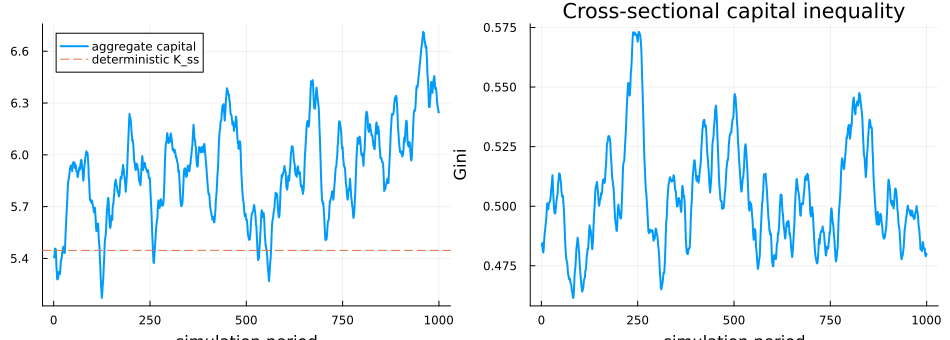

In [129]:
simulation = simulate_economy(result.theta, par, ss;
    periods=1000, burn=200, seed=404)
aggregation = approximate_aggregation(simulation)

@printf("mean aggregate capital = %.4f (steady state %.4f)\n",
    mean(simulation.aggregate_k), ss.K)
@printf("mean capital Gini = %.4f\n", mean(simulation.capital_gini))
@printf("approximate-aggregation R² = %.5f\n", aggregation.r2)
@printf("log K(t+1) = %.4f + %.4f log K(t) + %.4f log z(t)\n",
    aggregation.coefficients...)

p_k = plot(simulation.aggregate_k, lw=2, label="aggregate capital",
    xlabel="simulation period")
hline!(p_k, [ss.K], ls=:dash, label="deterministic K_ss")
p_g = plot(simulation.capital_gini, lw=2, label=false,
    xlabel="simulation period", ylabel="Gini",
    title="Cross-sectional capital inequality")
p_simulation = plot(p_k, p_g, layout=(1, 2), size=(950, 340))
p_simulation

### 8.4 Consumption and savings rules

The last diagnostic makes the high-dimensional policy interpretable. It holds the other 99 households and aggregate productivity fixed at one simulated cross section, varies household 1's cash on hand over a grid, and repeats this for several productivity levels.

Each plotted point still conditions on the full $(W,Y,z)$ distribution. The figure therefore shows a conditional slice of the learned high-dimensional consumption and saving rules, not a policy that depends only on individual wealth.

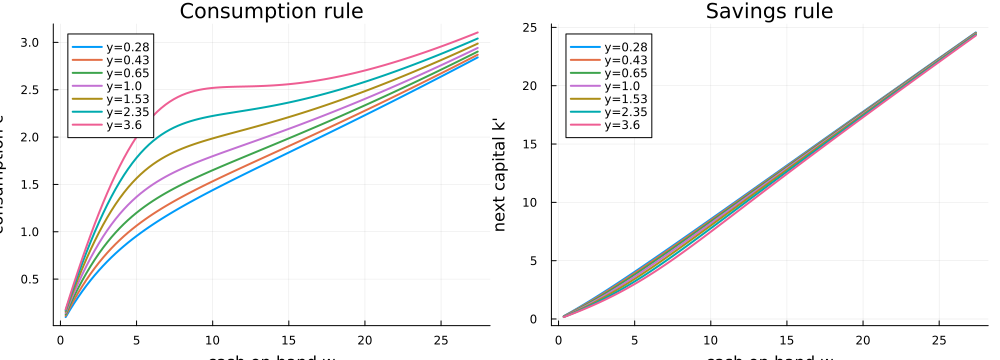

In [130]:
slice = policy_slice(result.theta, simulation.final_state, par, ss;
    agent=1, points=100, productivity_points=7)

p_c = plot(xlabel="cash on hand w", ylabel="consumption c",
    title="Consumption rule")
p_s = plot(xlabel="cash on hand w", ylabel="next capital k'",
    title="Savings rule")
for j in eachindex(slice.productivity_grid)
    label = "y=$(round(slice.productivity_grid[j], digits=2))"
    plot!(p_c, slice.wealth_grid, slice.consumption[:, j], lw=2, label=label)
    plot!(p_s, slice.wealth_grid, slice.savings[:, j], lw=2, label=label)
end
p_policy = plot(p_c, p_s, layout=(1, 2), size=(1000, 360))
p_policy

### Interpreting the conditional policy slices

The horizontal axis is current cash on hand $w$, not current capital. Because the budget identity is $k'=w-c$, a savings curve close to the 45-degree line is not by itself evidence of an error: if consumption rises slowly with wealth, then $k'$ naturally rises almost one-for-one with $w$. The more important warning sign is the non-monotone consumption curve at the highest productivity values.

This figure evaluates a rectangular grid,

$$
w\in[0.05W_{ss},4W_{ss}],\qquad \log y\in[-2\sigma_{y,\infty},2\sigma_{y,\infty}],
$$

while holding the other 99 households and aggregate productivity fixed at one simulated cross section. The endogenous joint distribution of $(w,y,D,z)$ is not rectangular. High wealth is observed less often than middle wealth, $y=3.6$ lies in the extreme productivity tail, and combinations such as high $y$ with an arbitrary $w$ may be essentially absent from the simulation. The network is therefore interpolating near the dense center of the ergodic set but extrapolating for some curves shown here.

This matters because the training loss averages residuals over simulated household states. Frequently visited states receive many gradient updates, whereas rare tail combinations have little influence. A fully connected network has no built-in restriction requiring $\partial c/\partial w\ge0$, so weakly trained tail regions can display humps, crossings, or locally decreasing consumption even when the policy behaves sensibly on the central support. The figure is therefore useful precisely because it reveals a coverage limitation; it should not be interpreted as a uniformly accurate global policy map.

A better diagnostic should construct the grid from the empirical joint support. Use wealth between its simulated 5th and 95th percentiles, choose productivity levels at the simulated 10th, 50th, and 90th percentiles, report how many training observations lie near each plotted curve, and evaluate Euler errors separately by wealth-productivity bin. For a more accurate tail solution, retain rare states in a replay buffer, oversample top-wealth and extreme-productivity households in an auxiliary tail loss, simulate several dispersed initial cross sections, and optionally add a monotonicity penalty such as

$$
\lambda_{mono}E\left[\min\left(0,\frac{\partial c}{\partial w}\right)^2\right].
$$

These changes improve coverage without replacing the distribution by aggregate capital. Until such checks are added, the central-support policy and the out-of-sample Euler diagnostics are informative, but the extreme curves should be labeled as extrapolation rather than treated as a solved part of the state space.